# model charts: walk-forward, how good it is, what drives it, and the $300M backtest

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#a3a29c"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False,
})


def money(x, _=None):
    for size, unit in [(1e9, "B"), (1e6, "M"), (1e3, "k")]:
        if abs(x) >= size:
            return f"${x / size:g}{unit}"
    return f"${x:g}"


MONEY = FuncFormatter(money)
PCT = PercentFormatter(1.0, decimals=0)
RATING_RANGE = (5.5, 7.0)  # same scale on every rating chart so small gaps don't look huge


def save(fig, name):
    fig.savefig(f"../figures/{name}.png")


def dots(ax, labels, series, title):
    # horizontal dot plot. series is a list of (values, color, name)
    y = np.arange(len(labels))
    for values, color, name in series:
        ax.scatter(values, y, color=color, s=34, label=name, zorder=3)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)
    ax.set_title(title)


def legend_below(ax):
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2, fontsize=8.5)

In [2]:
d = pd.read_csv("../data/processed/movies_clean.csv")
pred = pd.read_csv("../data/processed/predictions_cast.csv")
folds = pd.read_csv("../data/processed/fold_metrics_cast.csv")
importance = pd.read_csv("../data/processed/feature_importance_cast.csv", index_col=0)["mean_abs_shap"]
draws = pd.read_csv("../data/processed/backtest_draws.csv")
picks = pd.read_csv("../data/processed/backtest_model_picks.csv")
picks = picks[picks["penalty"] == 0.25]  # the risk-adjusted slate i went with

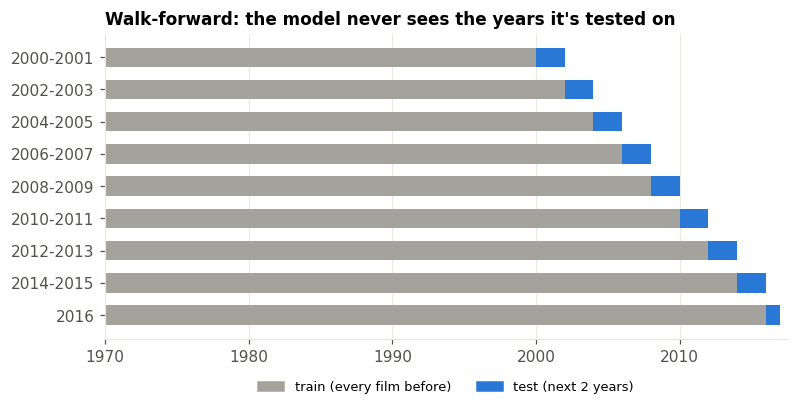

In [3]:
# walk-forward: each row is one fold. train on everything before, test on the next 2 years
fig, ax = plt.subplots(figsize=(8, 3.6))
starts = list(range(2000, 2017, 2))
for row, start in enumerate(starts):
    end = min(start + 1, 2016)
    ax.barh(row, start - 1970, left=1970, color=GRAY, height=0.6)
    ax.barh(row, end - start + 1, left=start, color=BLUE, height=0.6)
ax.set_yticks(range(len(starts)), [f"{s}-{min(s + 1, 2016)}" if s < 2016 else "2016" for s in starts])
ax.invert_yaxis()
ax.set_xlim(1970, 2017.5)
ax.grid(axis="y", visible=False)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GRAY, label="train (every film before)"), Patch(color=BLUE, label="test (next 2 years)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=8.5)
ax.set_title("Walk-forward: the model never sees the years it's tested on")
save(fig, "11_walk_forward")

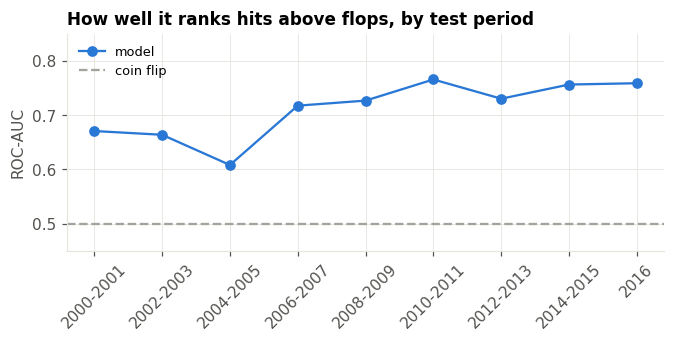

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.4))
x = np.arange(len(folds))
ax.plot(x, folds["roc_auc"], color=BLUE, marker="o", label="model")
ax.axhline(0.5, color=GRAY, linestyle="--", label="coin flip")
ax.set_xticks(x, folds["years"].str.replace("2016-2016", "2016"), rotation=45)
ax.set_ylim(0.45, 0.85)
ax.set_ylabel("ROC-AUC")
ax.legend(loc="upper left", fontsize=8.5)
ax.set_title("How well it ranks hits above flops, by test period")
fig.subplots_adjust(bottom=0.3)
save(fig, "12_auc_by_fold")

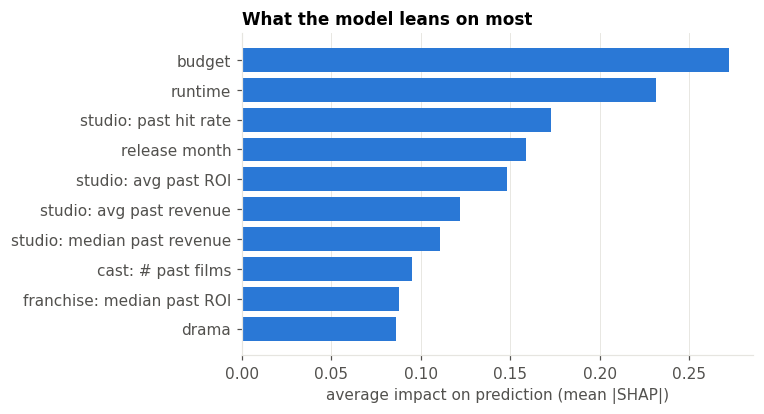

In [5]:
# plain names for the top features
labels = {
    "log_budget": "budget", "runtime": "runtime", "month": "release month", "year": "year",
    "studio_mean_roi": "studio: avg past ROI", "studio_hit_rate": "studio: past hit rate",
    "studio_median_revenue": "studio: median past revenue", "studio_mean_revenue": "studio: avg past revenue",
    "studio_median_roi": "studio: median past ROI", "studio_n_prior": "studio: # past films",
    "franchise_median_roi": "franchise: median past ROI", "cast_n_prior": "cast: # past films",
    "cast_median_roi": "cast: median past ROI", "cast_mean_revenue": "cast: avg past revenue",
    "genre_drama": "drama", "is_independent": "independent",
}
top = importance.head(10)[::-1]
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh([labels.get(f, f) for f in top.index], top.values, color=BLUE)
ax.grid(axis="y", visible=False)
ax.set_xlabel("average impact on prediction (mean |SHAP|)")
ax.set_title("What the model leans on most")
save(fig, "13_shap_top")

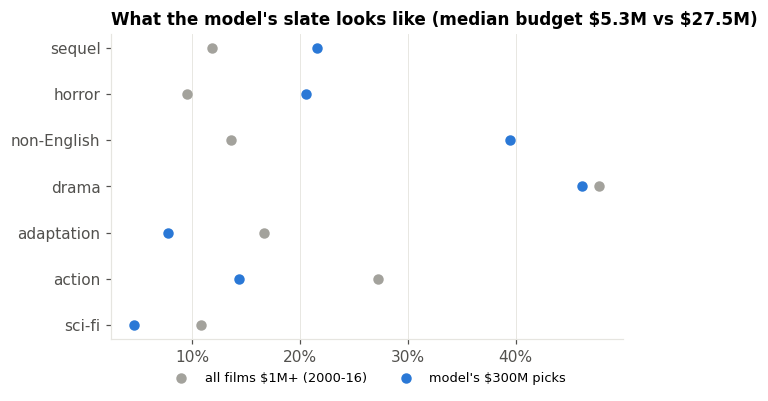

In [6]:
pool = pred[pred["budget_real"] >= 1e6]
traits = {"sequel": "is_sequel", "horror": "genre_horror", "non-English": None, "drama": "genre_drama",
          "adaptation": "is_adaptation", "action": "genre_action", "sci-fi": "genre_science_fiction"}

def share(films, col):
    return 1 - films["is_english"].mean() if col is None else films[col].mean()

names = list(traits)[::-1]
fig, ax = plt.subplots(figsize=(6, 3.6))
dots(ax, names, [([share(pool, traits[n]) for n in names], GRAY, "all films $1M+ (2000-16)"),
                 ([share(picks, traits[n]) for n in names], BLUE, "model's $300M picks")],
     f"What the model's slate looks like (median budget \${picks['budget_real'].median() / 1e6:.1f}M "
     f"vs \${pool['budget_real'].median() / 1e6:.1f}M)")
ax.xaxis.set_major_formatter(PCT)
legend_below(ax)
save(fig, "14_picks_vs_pool")

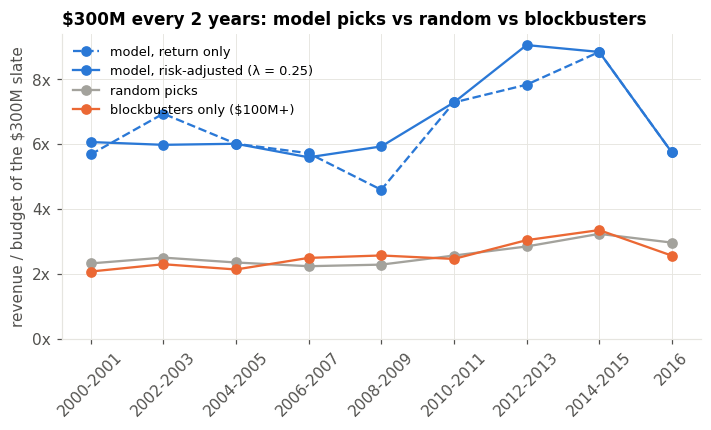

In [7]:
per_block = draws.groupby(["strategy", "block", "draw"])["multiple"].first().groupby(["strategy", "block"])
mid, low, high = per_block.median().unstack(0), per_block.quantile(0.05).unstack(0), per_block.quantile(0.95).unstack(0)
blocks = mid.index
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for strategy, color, style, name in [("model_risk_0", BLUE, "--", "model, return only"),
                                     ("model_risk_0.25", BLUE, "-", "model, risk-adjusted (λ = 0.25)"),
                                     ("random", GRAY, "-", "random picks"),
                                     ("blockbuster", ORANGE, "-", "blockbusters only ($100M+)")]:
    ax.plot(blocks, mid[strategy], color=color, linestyle=style, marker="o", label=name)
ax.set_xticks(blocks, [f"{b}-{b + 1}" if b < 2016 else "2016" for b in blocks], rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
ax.set_ylim(0, None)
ax.set_ylabel("revenue / budget of the $300M slate")
ax.legend(loc="upper left", fontsize=8.5)
ax.set_title("$300M every 2 years: model picks vs random vs blockbusters")
save(fig, "15_backtest_by_block")

0.89 0.11 0.11 [0.41 1.69 3.36 9.26] 2.4


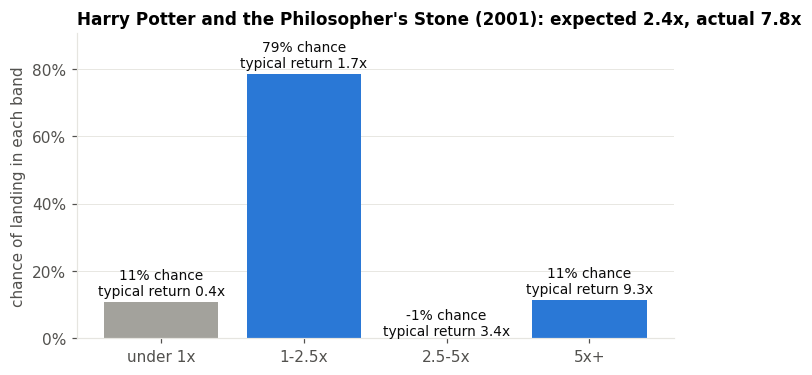

In [8]:
# worked example: how the 1x, 2.5x and 5x models combine into one expected multiple
film = pred[pred["title"] == "Harry Potter and the Philosopher's Stone"].iloc[0]
p1, p2_5, p5 = film["pred"], film["pred_2.5x"], film["pred_5x"]
chances = [1 - p1, p1 - p2_5, p2_5 - p5, p5]

# band medians come from the years the model trained on, same as in model.py
train_roi = d.loc[d["year"] < film["year"] // 2 * 2, "roi"]
medians = train_roi.groupby(pd.cut(train_roi, [0, 1, 2.5, 5, np.inf])).median().values
bands = ["under 1x", "1-2.5x", "2.5-5x", "5x+"]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(bands, chances, color=[GRAY, BLUE, BLUE, BLUE])
for i, (c, m) in enumerate(zip(chances, medians)):
    ax.text(i, c + 0.01, f"{c:.0%} chance\ntypical return {m:.1f}x", ha="center", va="bottom", fontsize=9, color=INK)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, max(chances) + 0.12)
ax.grid(axis="x", visible=False)
ax.set_ylabel("chance of landing in each band")
expected = sum(c * m for c, m in zip(chances, medians))
ax.set_title(f"{film['title']} ({film['year']:.0f}): expected {expected:.1f}x, actual {film['roi']:.1f}x")
save(fig, "16_three_models_example")
print(round(p1, 2), round(p2_5, 2), round(p5, 2), medians.round(2), round(expected, 2))

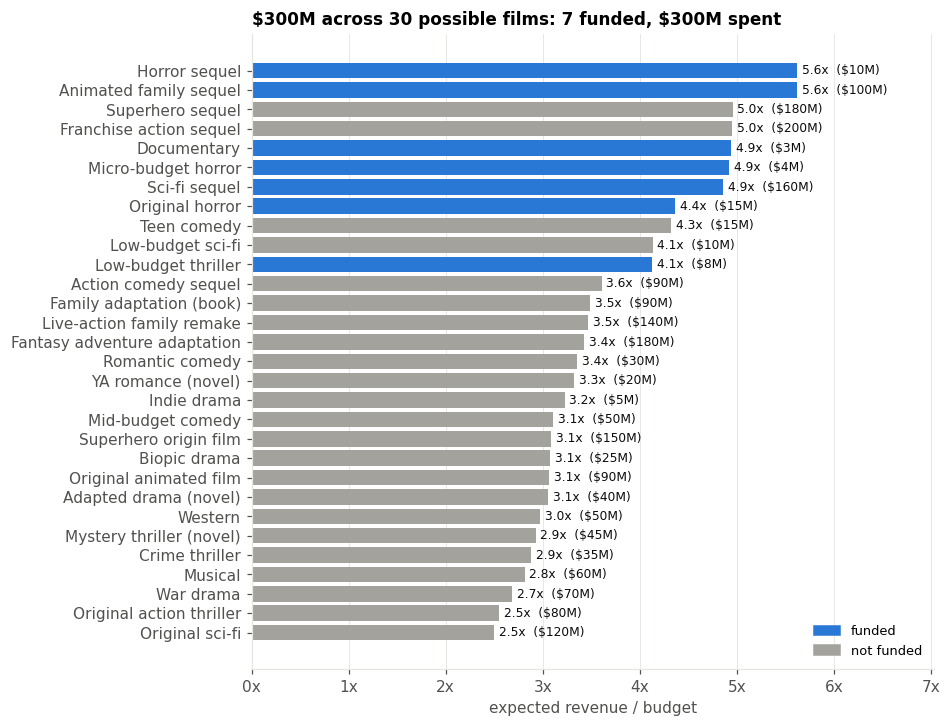

In [9]:
# the 30 made-up films for next year, and which ones the model funds with $300M
future = pd.read_csv("../data/processed/future_profiles.csv").sort_values("exp_multiple")
funded = future[future["funded"]]
fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(future["name"], future["exp_multiple"], color=np.where(future["funded"], BLUE, GRAY))
for y, (_, film) in enumerate(future.iterrows()):
    ax.text(film["exp_multiple"] + 0.05, y, f"{film['exp_multiple']:.1f}x  ({money(film['budget_real'])})",
            va="center", fontsize=8, color=INK)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}x"))
ax.set_xlim(0, future["exp_multiple"].max() * 1.25)
ax.grid(axis="y", visible=False)
ax.set_xlabel("expected revenue / budget")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="funded"), Patch(color=GRAY, label="not funded")], loc="lower right", fontsize=8.5)
spent = money(funded["budget_real"].sum()).replace("$", "\\$")  # two $ signs in a title turn into math text
ax.set_title(f"\\$300M across 30 possible films: {len(funded)} funded, {spent} spent")
save(fig, "17_future_slate")

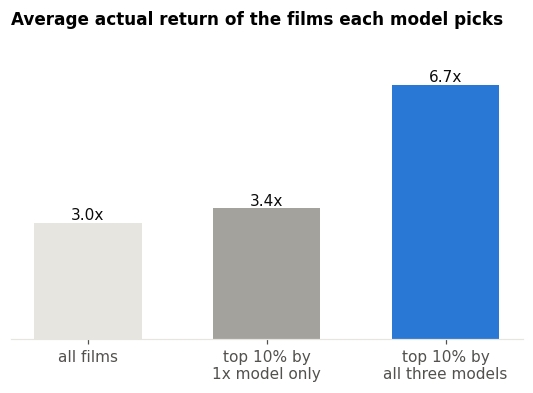

In [10]:
# do the 2.5x and 5x models pick better films than the 1x model alone?
# take the 10% of films each version rates highest (2000-16, every film scored by a model that never saw it)
scored = pd.read_csv("../data/processed/backtest_scored.csv")
scored["capped"] = scored["roi"].clip(upper=50)  # a few films made 100x+, so they count as 50x here

def top_10_return(col):
    return scored.loc[scored[col] >= scored[col].quantile(0.9), "capped"].mean()

labels = ["all films", "top 10% by\n1x model only", "top 10% by\nall three models"]
values = [scored["capped"].mean(), top_10_return("exp_multiple_1x"), top_10_return("exp_multiple")]
fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar(labels, values, color=[GRID, GRAY, BLUE], width=0.6)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}x", ha="center", va="bottom", fontsize=10, color=INK)
ax.set_yticks([])
ax.grid(visible=False)
ax.spines["left"].set_visible(False)
ax.set_ylim(0, max(values) * 1.2)
ax.set_title("Average actual return of the films each model picks")
save(fig, "18_three_vs_one")